# Missing Data

在 Pandas 中，為了表示缺失值，引入了一個新的值 pd.NA（單例）。之前，Pandas 使用多個值來表示缺失數

據：對於浮點數據使用 np.nan，對於對象類型數據使用 np.nan 或 None，對於類似日期時間的數據使用

pd.NaT。pd.NA 的目標是提供一個可以在不同數據類型之間一致使用的“缺失”指標。目前，pd.NA 被應用於可空

的整數和布爾數據類型以及新的字符串數據類型。

In [125]:
import numpy as np
import pandas as pd

print(np.nan)
print(type(np.nan))

nan
<class 'float'>


In [126]:
print(pd.NA)
print(type(pd.NA))

<NA>
<class 'pandas._libs.missing.NAType'>


In [127]:
print(None)

None


In [128]:
np.nan == np.nan

False

In [129]:
np.nan is np.nan

True

In [130]:
np.nan in [np.nan] 

True

In [131]:
pd.NA == pd.NA

<NA>

In [132]:
pd.NA is pd.NA

True

In [133]:
pd.NA in [pd.NA]

True

In [134]:
df = pd.read_csv("movie_scores.csv")
df.head()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [135]:
df.isnull()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,False,False,False,False,False,False
1,True,True,True,True,True,True
2,False,False,False,False,True,True
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [136]:
df.notnull()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,True,True,True,True,True,True
1,False,False,False,False,False,False
2,True,True,True,True,False,False
3,True,True,True,True,True,True
4,True,True,True,True,True,True


In [137]:
df[df["first_name"].notnull()]

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [138]:
df[(df["pre_movie_score"].isnull()) & (df["sex"].notnull())]

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
2,Hugh,Jackman,51.0,m,NaN,NaN


In [139]:
df

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [140]:
df.dropna()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [141]:
df.dropna(thresh=2)#軸0至少2筆是有數值的就留下來

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [142]:
df.dropna(axis=1,thresh=4)#軸1至少4筆是有數值的就留下來

,first_name,last_name,age,sex
0,Tom,Hanks,63.0,m
1,NaN,NaN,NaN,NaN
2,Hugh,Jackman,51.0,m
3,Oprah,Winfrey,66.0,f
4,Emma,Stone,31.0,f


In [143]:
df.fillna("Missing")

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
1,Missing,Missing,Missing,Missing,Missing,Missing
2,Hugh,Jackman,51.0,m,Missing,Missing
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [144]:
df["first_name"].fillna("Empty")

0      Tom
1    Empty
2     Hugh
3    Oprah
4     Emma
Name: first_name, dtype: object

In [145]:
print(df["post_movie_score"].mean())
df["post_movie_score"].fillna(df["post_movie_score"].mean())

9.0


0    10.0
1     9.0
2     9.0
3     8.0
4     9.0
Name: post_movie_score, dtype: float64

## Data


mpg 通常代表 "miles per gallon"，這是一個測量汽車燃油效率的指標，意指每加侖汽油可以行駛的英里數。

這個指標幫助消費者理解汽車在標準條件下的燃油經濟性。高的 mpg 值表示汽車更加節能，因為它可以在消耗較少的燃料的情況下行駛更長的距離。這是評估汽車性能的一個重要指標，尤其在考慮環保和經濟性時更是如此。
其他欄位如 cylinders（氣缸數）、
displacement（排氣量）

、horsepower（馬力）、weight（重量）、

acceleration（加速度）、

model_year（型號年份）、

origin（產地）和 

name（車型名稱），

In [146]:
df = pd.read_csv("mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [147]:
g = df.groupby("model_year")
print(list(g))

[(70,      mpg  cylinders  displacement horsepower  weight  acceleration  \
0   18.0          8         307.0        130    3504          12.0   
1   15.0          8         350.0        165    3693          11.5   
2   18.0          8         318.0        150    3436          11.0   
3   16.0          8         304.0        150    3433          12.0   
4   17.0          8         302.0        140    3449          10.5   
5   15.0          8         429.0        198    4341          10.0   
6   14.0          8         454.0        220    4354           9.0   
7   14.0          8         440.0        215    4312           8.5   
8   14.0          8         455.0        225    4425          10.0   
9   15.0          8         390.0        190    3850           8.5   
10  15.0          8         383.0        170    3563          10.0   
11  14.0          8         340.0        160    3609           8.0   
12  15.0          8         400.0        150    3761           9.5   
13  14.0      

#### Adding an aggregate method call. To use a grouped object, you need to tell pandas how you want to aggregate the data.

Common Options:

    mean(): Compute mean of groups
    sum(): Compute sum of group values
    size(): Compute group sizes
    count(): Compute count of group
    std(): Standard deviation of groups
    var(): Compute variance of groups
    sem(): Standard error of the mean of groups
    describe(): Generates descriptive statistics
    first(): Compute first of group values
    last(): Compute last of group values
    nth() : Take nth value, or a subset if n is a list
    min(): Compute min of group values
    max(): Compute max of group values
    
Full List at the Online Documentation: https://pandas.pydata.org/docs/reference/groupby.html

In [148]:
g = df.groupby("model_year")
gSum = g.sum()
gSum.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,name
model_year,,,,,,,,
70,513.0,196,8161.0,1301651501501401982202152251901701601502259595...,97811,375.5,38,chevrolet chevelle malibubuick skylark 320plym...
71,595.0,156,5873.0,889095?100105100881001651751531501801701751107...,83872,424.0,40,datsun pl510chevrolet vega 2300toyota coronafo...
72,524.0,163,6114.5,9580549086165175150153150208155160190971501301...,90656,423.5,43,toyota corona hardtopdodge colt hardtopvolkswa...
73,684.0,255,10275.0,1751501451371501981501581502152251751051001008...,136761,572.5,55,buick century 350amc matadorchevrolet malibufo...
74,613.0,142,4637.0,95?1001006780657510011010514015015014015083677...,77704,437.5,45,plymouth dusterford maverickamc hornetchevrole...


In [149]:
meanG = g.mean(numeric_only=True)
meanG.head()

,mpg,cylinders,displacement,weight,acceleration,origin
model_year,,,,,,
70,17.689655,6.758621,281.413793,3372.793103,12.948276,1.310345
71,21.250000,5.571429,209.750000,2995.428571,15.142857,1.428571
72,18.714286,5.821429,218.375000,3237.714286,15.125000,1.535714
73,17.100000,6.375000,256.875000,3419.025000,14.312500,1.375000
74,22.703704,5.259259,171.740741,2877.925926,16.203704,1.666667


In [150]:
meanG["cylinders"].iloc[0:5]

model_year
70    6.758621
71    5.571429
72    5.821429
73    6.375000
74    5.259259
Name: cylinders, dtype: float64

In [151]:
meanG.describe()

,mpg,cylinders,displacement,weight,acceleration,origin
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,23.659059,5.433688,192.106073,2960.466485,15.589128,1.579195
std,5.308042,0.761233,47.662157,325.173903,1.051988,0.260025
min,17.100000,4.137931,115.827586,2436.655172,12.948276,1.275862
25%,20.266667,5.259259,171.740741,2861.805556,15.142857,1.428571
50%,22.703704,5.571429,197.794118,2997.357143,15.813793,1.535714
75%,25.093103,5.821429,209.750000,3176.800000,16.203704,1.645161
max,33.696552,6.758621,281.413793,3419.025000,16.934483,2.206897


In [152]:
meanG.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,13.0,23.659059,5.308042,17.100000,20.266667,22.703704,25.093103,33.696552
cylinders,13.0,5.433688,0.761233,4.137931,5.259259,5.571429,5.821429,6.758621
displacement,13.0,192.106073,47.662157,115.827586,171.740741,197.794118,209.750000,281.413793
weight,13.0,2960.466485,325.173903,2436.655172,2861.805556,2997.357143,3176.800000,3419.025000
acceleration,13.0,15.589128,1.051988,12.948276,15.142857,15.813793,16.203704,16.934483
origin,13.0,1.579195,0.260025,1.275862,1.428571,1.535714,1.645161,2.206897


In [153]:
meanG.head()

,mpg,cylinders,displacement,weight,acceleration,origin
model_year,,,,,,
70,17.689655,6.758621,281.413793,3372.793103,12.948276,1.310345
71,21.250000,5.571429,209.750000,2995.428571,15.142857,1.428571
72,18.714286,5.821429,218.375000,3237.714286,15.125000,1.535714
73,17.100000,6.375000,256.875000,3419.025000,14.312500,1.375000
74,22.703704,5.259259,171.740741,2877.925926,16.203704,1.666667


In [154]:
meanG.loc[70:73,"mpg":"weight"]

,mpg,cylinders,displacement,weight
model_year,,,,
70,17.689655,6.758621,281.413793,3372.793103
71,21.250000,5.571429,209.750000,2995.428571
72,18.714286,5.821429,218.375000,3237.714286
73,17.100000,6.375000,256.875000,3419.025000


In [155]:
mcgroup = df.groupby(["model_year","cylinders"])
print(list(mcgroup))

[((70, 4),      mpg  cylinders  displacement horsepower  weight  acceleration  \
14  24.0          4         113.0         95    2372          15.0   
18  27.0          4          97.0         88    2130          14.5   
19  26.0          4          97.0         46    1835          20.5   
20  25.0          4         110.0         87    2672          17.5   
21  24.0          4         107.0         90    2430          14.5   
22  25.0          4         104.0         95    2375          17.5   
23  26.0          4         121.0        113    2234          12.5   

    model_year  origin                          name  
14          70       3         toyota corona mark ii  
18          70       3                  datsun pl510  
19          70       2  volkswagen 1131 deluxe sedan  
20          70       2                   peugeot 504  
21          70       2                   audi 100 ls  
22          70       2                      saab 99e  
23          70       2                     

In [156]:
mcmean = mcgroup.mean(numeric_only=True)
mcmean.head()

mpg  displacement       weight  acceleration  \
model_year cylinders                                                       
70         4          25.285714    107.000000  2292.571429     16.000000   
           6          20.500000    199.000000  2710.500000     15.500000   
           8          14.111111    367.555556  3940.055556     11.194444   
71         4          27.461538    101.846154  2056.384615     16.961538   
           6          18.000000    243.375000  3171.875000     14.750000   

                        origin  
model_year cylinders            
70         4          2.285714  
           6          1.000000  
           8          1.000000  
71         4          1.923077  
           6          1.000000

In [157]:
mcmean.index

MultiIndex([(70, 4),
            (70, 6),
            (70, 8),
            (71, 4),
            (71, 6),
            (71, 8),
            (72, 3),
            (72, 4),
            (72, 8),
            (73, 3),
            (73, 4),
            (73, 6),
            (73, 8),
            (74, 4),
            (74, 6),
            (74, 8),
            (75, 4),
            (75, 6),
            (75, 8),
            (76, 4),
            (76, 6),
            (76, 8),
            (77, 3),
            (77, 4),
            (77, 6),
            (77, 8),
            (78, 4),
            (78, 5),
            (78, 6),
            (78, 8),
            (79, 4),
            (79, 5),
            (79, 6),
            (79, 8),
            (80, 3),
            (80, 4),
            (80, 5),
            (80, 6),
            (81, 4),
            (81, 6),
            (81, 8),
            (82, 4),
            (82, 6)],
           names=['model_year', 'cylinders'])

In [158]:
mcmean.head(5)

mpg  displacement       weight  acceleration  \
model_year cylinders                                                       
70         4          25.285714    107.000000  2292.571429     16.000000   
           6          20.500000    199.000000  2710.500000     15.500000   
           8          14.111111    367.555556  3940.055556     11.194444   
71         4          27.461538    101.846154  2056.384615     16.961538   
           6          18.000000    243.375000  3171.875000     14.750000   

                        origin  
model_year cylinders            
70         4          2.285714  
           6          1.000000  
           8          1.000000  
71         4          1.923077  
           6          1.000000

In [159]:
mcmean.loc[70:75]

mpg  displacement       weight  acceleration  \
model_year cylinders                                                       
70         4          25.285714    107.000000  2292.571429     16.000000   
           6          20.500000    199.000000  2710.500000     15.500000   
           8          14.111111    367.555556  3940.055556     11.194444   
71         4          27.461538    101.846154  2056.384615     16.961538   
           6          18.000000    243.375000  3171.875000     14.750000   
           8          13.428571    371.714286  4537.714286     12.214286   
72         3          19.000000     70.000000  2330.000000     13.500000   
           4          23.428571    111.535714  2382.642857     17.214286   
           8          13.615385    344.846154  4228.384615     13.000000   
73         3          18.000000     70.000000  2124.000000     13.500000   
           4          22.727273    109.272727  2338.090909     17.136364   
           6          19.000000    212.250000  2917.125000     15.687500   
           8          13.200000    365.250000  4279.050000     12.250000   
74         4          27.800000     96.533333  2151.466667     16.400000   
           6          17.857143    230.428571  3320.000000     16.857143   
           8          14.200000    315.200000  4438.400000     14.700000   
75         4          25.250000    114.833333  2489.250000     15.833333   
           6          17.583333    233.750000  3398.333333     17.708333   
           8          15.666667    330.500000  4108.833333     13.166667   

                        origin  
model_year cylinders            
70         4          2.285714  
           6          1.000000  
           8          1.000000  
71         4          1.923077  
           6          1.000000  
           8          1.000000  
72         3          3.000000  
           4          1.928571  
           8          1.000000  
73         3          3.000000  
           4          2.000000  
           6          1.250000  
           8          1.000000  
74         4          2.200000  
           6          1.000000  
           8          1.000000  
75         4          2.166667  
           6          1.000000  
           8          1.000000

In [160]:
mcmean.loc[(71,4):(74,6),"displacement":"weight"]

displacement       weight
model_year cylinders                           
71         4            101.846154  2056.384615
           6            243.375000  3171.875000
           8            371.714286  4537.714286
72         3             70.000000  2330.000000
           4            111.535714  2382.642857
           8            344.846154  4228.384615
73         3             70.000000  2124.000000
           4            109.272727  2338.090909
           6            212.250000  2917.125000
           8            365.250000  4279.050000
74         4             96.533333  2151.466667
           6            230.428571  3320.000000

In [161]:
mcmean.head(5)

mpg  displacement       weight  acceleration  \
model_year cylinders                                                       
70         4          25.285714    107.000000  2292.571429     16.000000   
           6          20.500000    199.000000  2710.500000     15.500000   
           8          14.111111    367.555556  3940.055556     11.194444   
71         4          27.461538    101.846154  2056.384615     16.961538   
           6          18.000000    243.375000  3171.875000     14.750000   

                        origin  
model_year cylinders            
70         4          2.285714  
           6          1.000000  
           8          1.000000  
71         4          1.923077  
           6          1.000000

## 用來根據索引（index）選取特定的行或列。
### key=70：選取索引值為 70 的資料。
### axis=0：從 行索引（row index） 選取資料。
### level="model_year"：如果 g 是一個 MultiIndex DataFrame，則 70 是 model_year 這個層級的索引值。


In [162]:
mcmean.xs(key=70,level="model_year",axis=0)

,mpg,displacement,weight,acceleration,origin
cylinders,,,,,
4,25.285714,107.000000,2292.571429,16.000000,2.285714
6,20.500000,199.000000,2710.500000,15.500000,1.000000
8,14.111111,367.555556,3940.055556,11.194444,1.000000


In [163]:
mcmean.xs(key=6,level="cylinders",axis=0)

,mpg,displacement,weight,acceleration,origin
model_year,,,,,
70,20.500000,199.000000,2710.500000,15.500000,1.000000
71,18.000000,243.375000,3171.875000,14.750000,1.000000
73,19.000000,212.250000,2917.125000,15.687500,1.250000
74,17.857143,230.428571,3320.000000,16.857143,1.000000
75,17.583333,233.750000,3398.333333,17.708333,1.000000
76,20.000000,221.400000,3349.600000,17.000000,1.300000
77,19.500000,220.400000,3383.000000,16.900000,1.400000
78,19.066667,213.250000,3314.166667,16.391667,1.166667
79,22.950000,205.666667,3025.833333,15.433333,1.000000


In [164]:
import pandas as pd
data_one = {'A': ['A0', 'A1', 'A2', 'A3'],'B': ['B0', 'B1', 'B2', 'B3']}
data_two = {'C': ['C0', 'C1', 'C2', 'C3'], 'D': ['D0', 'D1', 'D2', 'D3']}
one = pd.DataFrame(data_one)
two = pd.DataFrame(data_two)

In [165]:
one

,A,B
0,A0,B0
1,A1,B1
2,A2,B2
3,A3,B3


In [166]:
two

,C,D
0,C0,D0
1,C1,D1
2,C2,D2
3,C3,D3


In [167]:
axix0 = pd.concat([one,two],axis=0)
axix0

,A,B,C,D
0,A0,B0,NaN,NaN
1,A1,B1,NaN,NaN
2,A2,B2,NaN,NaN
3,A3,B3,NaN,NaN
0,NaN,NaN,C0,D0
1,NaN,NaN,C1,D1
2,NaN,NaN,C2,D2
3,NaN,NaN,C3,D3


In [168]:
axis1 = pd.concat([one,two],axis=1)
axis1

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


In [169]:
registrations = pd.DataFrame({'reg_id':[1,2,3,4],'name':['Andrew','Bobo','Claire','David']})
logins = pd.DataFrame({'log_id':[1,2,3,4],'name':['Xavier','Andrew','Yolanda','Bobo']})

In [170]:
registrations

,reg_id,name
0,1,Andrew
1,2,Bobo
2,3,Claire
3,4,David


In [171]:
logins

,log_id,name
0,1,Xavier
1,2,Andrew
2,3,Yolanda
3,4,Bobo


In [172]:
pd.merge(registrations,logins)

,reg_id,name,log_id
0,1,Andrew,2
1,2,Bobo,4


In [173]:
pd.merge(registrations,logins,how="left")

,reg_id,name,log_id
0,1,Andrew,2.0
1,2,Bobo,4.0
2,3,Claire,NaN
3,4,David,NaN


In [174]:
pd.merge(registrations,logins,how="right")

,reg_id,name,log_id
0,NaN,Xavier,1
1,1.0,Andrew,2
2,NaN,Yolanda,3
3,2.0,Bobo,4


In [175]:
pd.merge(registrations,logins,how="outer")

,reg_id,name,log_id
0,1.0,Andrew,2.0
1,2.0,Bobo,4.0
2,3.0,Claire,NaN
3,4.0,David,NaN
4,NaN,Xavier,1.0
5,NaN,Yolanda,3.0


# Pivot Tables(樞紐分析表)


樞紐分析數據有時能幫助澄清關係和連接。

有關各種相關樞紐方法的完整文檔： https://pandas.pydata.org/docs/user_guide/reshaping.html
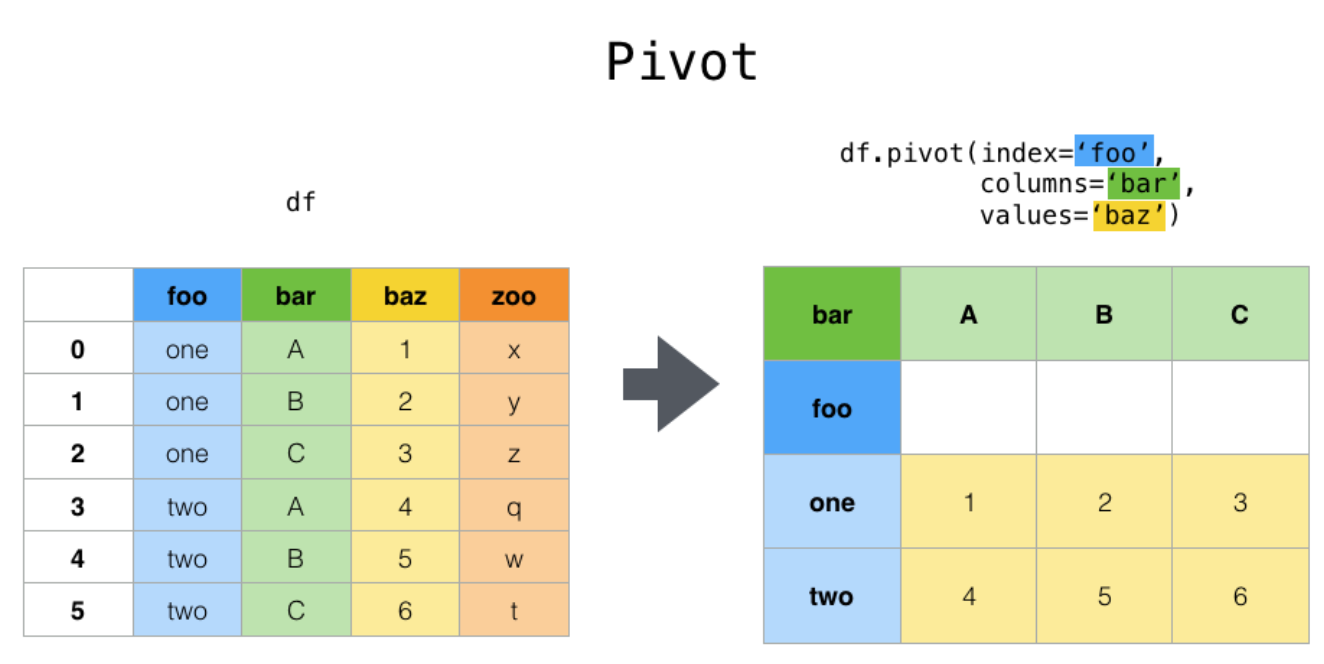

In [176]:
df = pd.read_csv("Sales_Funnel_CRM.csv")
df.head()

,Account Number,Company,Contact,Account Manager,Product,Licenses,Sale Price,Status
0,2123398,Google,Larry Pager,Edward Thorp,Analytics,150,2100000,Presented
1,2123398,Google,Larry Pager,Edward Thorp,Prediction,150,700000,Presented
2,2123398,Google,Larry Pager,Edward Thorp,Tracking,300,350000,Under Review
3,2192650,BOBO,Larry Pager,Edward Thorp,Analytics,150,2450000,Lost
4,420496,IKEA,Elon Tusk,Edward Thorp,Analytics,300,4550000,Won


In [177]:
licenses = df[["Company","Product","Licenses"]]
licenses

,Company,Product,Licenses
0,Google,Analytics,150
1,Google,Prediction,150
2,Google,Tracking,300
3,BOBO,Analytics,150
4,IKEA,Analytics,300
5,Tesla Inc.,Analytics,300
6,Tesla Inc.,Prediction,150
7,Microsoft,Tracking,300
8,Walmart,Analytics,150
9,Apple,Analytics,300


In [178]:
pd.pivot(data=licenses,index="Company",columns="Product",values="Licenses")

Product,Analytics,GPS Positioning,Prediction,Tracking
Company,,,,
Google,150.0,NaN,150.0,300.0
ATT,NaN,NaN,150.0,150.0
Apple,300.0,NaN,NaN,NaN
BOBO,150.0,NaN,NaN,NaN
CVS Health,NaN,NaN,NaN,450.0
Cisco,300.0,300.0,NaN,NaN
Exxon Mobile,150.0,NaN,NaN,NaN
IKEA,300.0,NaN,NaN,NaN
Microsoft,NaN,NaN,NaN,300.0


In [179]:
pd.pivot_table(df,index="Company",aggfunc="sum")

,Account Manager,Account Number,Contact,Licenses,Product,Sale Price,Status
Company,,,,,,,
Google,Edward ThorpEdward ThorpEdward Thorp,6370194,Larry PagerLarry PagerLarry Pager,600,AnalyticsPredictionTracking,3150000,PresentedPresentedUnder Review
ATT,Claude ShannonClaude Shannon,1396064,Cindy PhonerCindy Phoner,300,TrackingPrediction,1050000,Under ReviewPresented
Apple,Claude Shannon,405886,Cindy Phoner,300,Analytics,4550000,Won
BOBO,Edward Thorp,2192650,Larry Pager,150,Analytics,2450000,Lost
CVS Health,Claude Shannon,902797,Emma Gordian,450,Tracking,490000,Won
Cisco,Claude ShannonClaude Shannon,4338998,Emma GordianEmma Gordian,600,AnalyticsGPS Positioning,4900000,LostPresented
Exxon Mobile,Claude Shannon,470248,Cindy Phoner,150,Analytics,2100000,Presented
IKEA,Edward Thorp,420496,Elon Tusk,300,Analytics,4550000,Won
Microsoft,Edward Thorp,1216870,Will Grates,300,Tracking,350000,Under Review


In [180]:
pd.pivot_table(df,index="Company",aggfunc="sum",values=["Licenses","Sale Price"])

,Licenses,Sale Price
Company,,
Google,600,3150000
ATT,300,1050000
Apple,300,4550000
BOBO,150,2450000
CVS Health,450,490000
Cisco,600,4900000
Exxon Mobile,150,2100000
IKEA,300,4550000
Microsoft,300,350000


In [181]:
pd.pivot_table(df,index=["Account Manager","Contact"],aggfunc="sum",values=["Licenses","Sale Price"])


Licenses  Sale Price
Account Manager Contact                           
Claude Shannon  Cindy Phoner       750     7700000
                Emma Gordian      1800    12390000
Edward Thorp    Elon Tusk          750     8050000
                Larry Pager        750     5600000
                Will Grates        450     2800000

In [187]:
pd.pivot_table(df,index=["Account Manager","Contact"],values=["Licenses","Sale Price"],aggfunc="sum",columns=["Product"],fill_value=0)

Licenses                                      \
Product                      Analytics GPS Positioning Prediction Tracking   
Account Manager Contact                                                      
Claude Shannon  Cindy Phoner       450               0        150      150   
                Emma Gordian      1050             300          0      450   
Edward Thorp    Elon Tusk          600               0        150        0   
                Larry Pager        300               0        150      300   
                Will Grates        150               0          0      300   

                             Sale Price                                      
Product                       Analytics GPS Positioning Prediction Tracking  
Account Manager Contact                                                      
Claude Shannon  Cindy Phoner    6650000               0     700000   350000  
                Emma Gordian   11550000          350000          0   490000  
Edward Thorp    Elon Tusk       7350000               0     700000        0  
                Larry Pager     4550000               0     700000   350000  
                Will Grates     2450000               0          0   350000